In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
plt.rcParams.update({"text.usetex": True, "font.family": "serif", "font.serif": ["Computer Modern"],
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.titlesize": 12,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.2,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.03,})

In [8]:
isotopo = 87
route_ch1 = f"{isotopo}Rb/CH1.CSV"
route_ch2 = f"{isotopo}Rb/CH2.CSV"
data_ch1 = pd.read_csv(route_ch1)
data_ch2 = pd.read_csv(route_ch2)

voltages_ch1 = data_ch1["Voltage [V]"].to_numpy()
voltages_ch2 = data_ch2["Voltage [V]"].to_numpy()
time_ch1 = data_ch1["Time [s]"].to_numpy()
time_ch2 = data_ch2["Time [s]"].to_numpy()

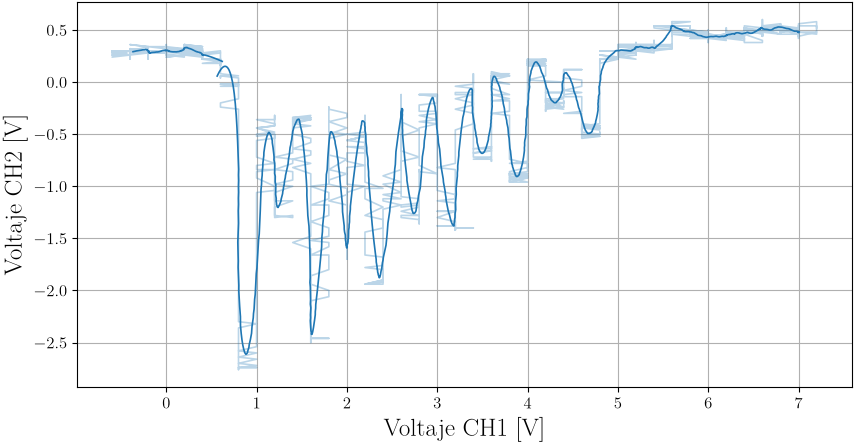

In [9]:
if isotopo == 85:
    a = 0
    b = -1
    w = 80
else:
    a = 0
    b = -1
    w = 80

vol_ch1_smooth = savgol_filter(
    voltages_ch1[a:b],
    window_length=w,
    polyorder=3
)

vol_ch2_smooth = savgol_filter(
    voltages_ch2[a:b],
    window_length=w,
    polyorder=3
)

fig, ax = plt.subplots(figsize = (10, 5))

ax.plot(voltages_ch1[a:b], voltages_ch2[a:b], alpha = 0.3, color = "#1f77b4")
ax.plot(vol_ch1_smooth, vol_ch2_smooth, color = "#1f77b4")
ax.set_ylabel("Voltaje CH2 [V]")
ax.set_xlabel("Voltaje CH1 [V]")
ax.grid(True)
plt.savefig(f"{isotopo}Rb.pdf")